# Chicago Crime

**Author:** Erik Pak  
**Date:** 04/2026  
**Data:** Chicago Data Portal - Crime Incidents 2001–2025

___
## Scope:
We are modeling crime incidence as a multivariate non-stationary stochastic process and detect crime type shifts via structural break detection across latent distributional parameters.

---
## Purpose: Dectecting structural shocks directly from the data itself.
    * COVID-type disruptions
    * Policy changes
    * Economic changes
    * Policing changes
    * Social unrest
---
## Sudden changes is statistical behaviors:
    * Mean suddenly increases
    * Variance suddenly increases
    * Trend changes direction
    * Seasonality changes
    * Volatility shifts

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Path + custom modules───
sys.path.append('../Src/')
import detection_config as cfg
import detection_analyze_fill as daf

# Library versions
versions = {
    "Python"  : sys.version.split()[0],
    "Pandas"  : pd.__version__,
    "NumPy"   : np.__version__,
    "Pyarrow" : pa.__version__,
    "Seaborn" : sns.__version__,
    "Matplot" : sys.modules['matplotlib'].__version__,
    "Scipy"   : sys.modules['scipy'].__version__,
}
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

   Library Version
0   Python  3.13.9
1   Pandas   2.3.3
2    NumPy   2.3.4
3  Pyarrow  22.0.0
4  Seaborn  0.13.2
5  Matplot  3.10.7
6    Scipy  1.16.3


## Data Import

In [2]:
# PyArrow's version of the 'arrow' backend
df = feather.read_feather('../Data/crime_data_covid.feather', memory_map=True, types_mapper=pd.ArrowDtype)
# display
df.head()

,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,...,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,year_week,year_month,Indexed
0,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,0324,...,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing,2001-04,200101,N
1,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,0624,...,Saturday,Q3,2003-Q3,Evening,Larceny – Theft,True,Gresham,2003-28,200307,I
2,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,True,False,1122,...,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison,2004-51,200412,N
3,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,2512,...,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central,2006-13,200603,I
4,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,True,False,2522,...,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central,2007-21,200705,N


In [3]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469443 entries, 0 to 8469442
Data columns (total 34 columns):
 #   Column                Non-Null Count    Dtype                                                       
---  ------                --------------    -----                                                       
 0   case_number           8469443 non-null  string[pyarrow]                                             
 1   date                  8469443 non-null  timestamp[s][pyarrow]                                       
 2   block                 8469443 non-null  string[pyarrow]                                             
 3   iucr                  8469443 non-null  string[pyarrow]                                             
 4   primary_type          8469443 non-null  string[pyarrow]                                             
 5   description           8469443 non-null  string[pyarrow]                                             
 6   location_description  8454105 non-

## Data Integration & Cleaning

In [4]:
# get the dates of period in the dataset
start_date = pd.to_datetime(df[cfg.config["_DATE_KEY"]].min(), format='%Y%m').date().strftime('%Y-%m')
end_date = pd.to_datetime(df[cfg.config["_DATE_KEY"]].max(), format='%Y%m').date().strftime('%Y-%m') 
# print the date range
print(f"Dataset covers from {start_date} to {end_date}")

Dataset covers from 2001-01 to 2025-12


### Check missingness & Fill missing data & Validate filled data

In [5]:
# Check integrity and missingness
integrity_results = daf.get_integrity_report(df)

# Fill missing data and report
fill_results = daf.fill_missing(df)

# Validate filled data
validation_results = daf.validate_crime_data(fill_results['filled_df'])


📊 Crime Data Integrity Report
Date Range:           2001-01 to 2025-12
Total Groups:         26
Total Months:         300
Total Records:        7,800
Total Missing Records: 275
Average Coverage:      96.47%
Minimum Coverage:      23.33%
Maximum Coverage:      100.00%

⚠️  Most Sparse Groups:
fbi_code_desc
Involuntary Manslaughter / Reckless Homicide    0.233333
Gambling                                        0.916667
Embezzlement                                    0.950000
Prostitution                                    0.990000
Stolen Property (Buy, Receive, Possess)         0.993333
Name: is_missing, dtype: float64


📊 Crime Data Filling Summary
Date Range:          2001-01 to 2025-12
Total Groups:        26
Total Periods:       300
Total Rows:          7,800
Filled Missing:      275
Fill Value Used:     0


🔍 CRIME DATA VALIDATION CHECK
✅ Date column is datetime
✅ Data is globally sorted by group and date
✅ All groups have strictly increasing dates
✅ All groups have consistent peri

In [6]:
# Info of the filled DataFrame
fill_results['filled_df'].info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7800 entries, 0 to 7799
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fbi_code_desc       7800 non-null   category      
 1   year_month          7800 non-null   datetime64[ns]
 2   crime_count         7800 non-null   float64       
 3   was_missing         7800 non-null   bool          
 4   is_zero_after_fill  7800 non-null   bool          
dtypes: bool(2), category(1), datetime64[ns](1), float64(1)
memory usage: 146.1 KB


### Compositional Data Analysis (CoDA)
**Compositional Data Analysis (CoDA)** is a specialized branch of statistics designed to analyze data that represent parts of a whole.

1. The Core Problem: The "Closed" Constraint
When data is compositional, the variables are inherently dependent. If one part of a composition increases, at least one other part must decrease to maintain the total.
    * This leads to three major issues in standard analysis:
        * **Spurious Correlation:** If you calculate a standard correlation matrix on percentages, you will often find strong negative correlations that aren't actually there in reality—they are just a result of the "sum-to-one" rule.
        * **The Simplex Space:** Compositional data exists in a geometric space called a Simplex, rather than the standard flat Euclidean space we are used to.
        * **Subcompositional Inconsistency:** If you remove one category from your dataset and re-calculate the percentages of the remaining ones, standard statistical results will change, which is logically inconsistent.
---

2. **Key Concepts in CoDA:**
* Scale Invariance
    * In CoDA, the absolute values don't matter; only the ratios between the parts carry information. For example, a composition of $(10, 20)$ contains the exact same information as $(100, 200)$; the second part is twice as large as the first.
* Log-Ratio Transformations
    * To use standard statistical tools (such as Mean, PCA, or Regression) on compositional data, we must first "open" the data by mapping it from the Simplex to Euclidean space. We do this using Log-Ratios.
* The most common transformations are:
    * **Additive Log-Ratio (ALR):** Picks one part as a denominator and takes the log of the ratios of all other parts to it.
    * **Centered Log-Ratio (CLR):** Takes the log of each part divided by the geometric mean of all parts.
    * **Isometric Log-Ratio (ILR):** The most mathematically robust method, which creates a new set of coordinates that are completely independent.
---

3. Real-World Applications
CoDA is essential in any field where data is relative:
    * **Geology:** Analyzing the chemical composition of rock samples (e.g., % Silica, % Iron, % Magnesium).
    * **Microbiology:** Analyzing the relative abundance of different bacteria in a gut microbiome sample.
    * **Economics:** Studying budget allocations (how a household splits income between rent, food, and savings).
    * **Social Science:** Analyzing crime profiles (like your Chicago data), where you want to know if the mix of crimes is changing, regardless of whether the total number of crimes is going up or down.
---
4. Why You Use It
Without CoDA, your models would be "blinded" by the total volume. If crime in Chicago drops by 50% across the board during a cold winter, a standard model might think the city has fundamentally changed. CoDA would show you that the composition (the ratio of thefts to assaults) remained identical, revealing that the underlying "nature" of crime hadn't shifted at all.
---
**Choice of CLR over ILR**
* ILR is the most mathematically complete transform; it produces orthonormal coordinates with no redundancy, but it has a practical cost: the resulting coordinates are linear combinations of log-ratios with no direct interpretation. You can't look at an ILR coordinate and say, "This is the Theft signal. CLR preserves one coordinate per crime type, so when PELT identifies a break, you can immediately read which CLR dimensions shifted most. For interpretability-first work, CLR is the right call. The one thing to keep in mind is that CLR produces a rank-deficient matrix (the 26 columns sum to zero row-wise), so if you ever feed it into something that inverts a covariance matrix directly, PCA, or Mahalanobis distance, you need to drop one column or use a pseudoinverse.
---

**ILR (Isometric Log‑Ratio)**  
ILR is the mathematically complete transform for compositional data. It produces an orthonormal coordinate system in $R^{D-1}$, with no redundancy and no singular covariance structure. This makes ILR ideal for:
* likelihood‑based modeling
* regression
* clustering
* distance‑based methods
* anything requiring a full‑rank covariance

But ILR coordinates are linear combinations of log‑ratios, so each coordinate corresponds to a contrast between balances of groups of components.
Because of that, ILR coordinates have no direct per‑crime interpretation. You cannot look at ILR and say “this is the Theft signal” or “this is the Burglary proportion.” Interpretability lies in the basis, not the coordinates.

---

**CLR (Centered Log‑Ratio)**
CLR preserves one coordinate per crime type, which makes it uniquely interpretable:
* When a break detector (PELT, BOCPD, etc.) fires, we can immediately inspect which CLR dimensions shifted.
* Each CLR coordinate corresponds directly to a crime category’s log‑ratio relative to the geometric mean.

This interpretability is why CLR is the right choice when your goal is:
* identifying which crime categories changed
* communicating results to analysts or stakeholders
* visualizing proportional shifts
* feeding breakpoints into downstream routing logic

The cost is mathematical:
* CLR lives in a rank‑deficient subspace (the coordinates sum to zero)
* The covariance matrix is singular
* Any method requiring matrix inversion (Mahalanobis, PCA, Gaussian models)
must either:
    * drop one CLR column, or
    * use a pseudoinverse, or
    * switch to ILR for that specific step

---

#### Note:
> * Use CLR when interpretability matters.  
> * We want to know which crime categories shifted.
> * Use ILR when you need full‑rank geometry.  
> * We want orthonormal coordinates for modeling or distance‑based methods.
> * Never feed raw CLR into anything that inverts a covariance matrix unless you drop a column or use a pseudoinverse.
> * Both transforms encode the same information; the difference is interpretability vs. mathematical convenience.

In [7]:
import numpy as np

# 1. Pivot to (T × K) count matrix — one row per month, one col per crime type
pivot = (
    fill_results['filled_df']
    .pivot(index=cfg.config["_DATE_KEY"], columns=cfg.config["_GROUP_KEY"], values="crime_count")
    .sort_index()
)
# 2. Monthly proportions — π_t = y_t / N_t
proportions = pivot.div(pivot.sum(axis=1), axis=0)
# 3. CLR transform - log(π_k) -mean(log(π_k)) per row
# Replace zeros first (0-fill -> small pseudocount before log)
eps = 0.5  # Laplace-style pseudocount, standard for compositional data
clr_input = pivot.add(eps)
props_smoothed = clr_input.div(clr_input.sum(axis=1), axis=0)
log_props = np.log(props_smoothed)
clr = log_props.sub(log_props.mean(axis=1), axis=0)  # shape (300, 26)

Pivot shape     : (300, 26)
Proportions shape: (300, 26)
CLR shape       : (300, 26)

Proportion row sums — min/max: 1.0 1.0
CLR row sums    — max abs   : 0.0
CLR NaNs        : 0
CLR Infs        : 0

Zero % by crime type (top 8):
fbi_code_desc
Involuntary Manslaughter / Reckless Homicide    0.7667
Gambling                                        0.0833
Embezzlement                                    0.0500
Prostitution                                    0.0100
Stolen Property (Buy, Receive, Possess)         0.0067
Aggravated Assault                              0.0000
Miscellaneous Non-Index Offenses                0.0000
Vandalism                                       0.0000


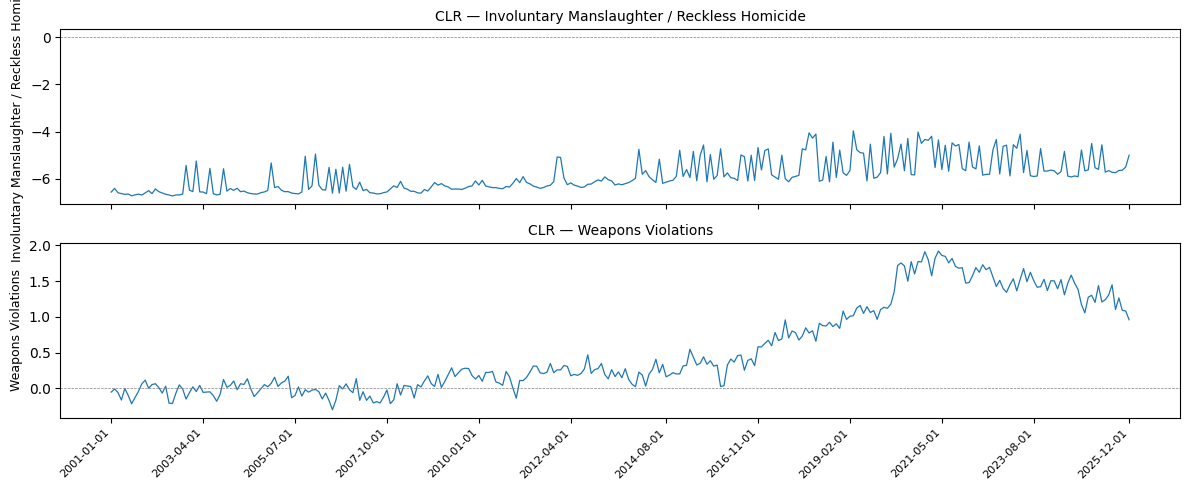

In [8]:
# --- Sanity checks

# 1. Shape
print("Pivot shape     :", pivot.shape)           # (300, 26)
print("Proportions shape:", proportions.shape)    # (300, 26)
print("CLR shape       :", clr.shape)             # (300, 26)

# 2. Proportions sum to 1 per row (should be all ~1.0)
row_sums = proportions.sum(axis=1)
print("\nProportion row sums — min/max:", row_sums.min().round(6), row_sums.max().round(6))

# 3. CLR rows sum to ~0 (fundamental CLR constraint)
clr_row_sums = clr.sum(axis=1)
print("CLR row sums    — max abs   :", clr_row_sums.abs().max().round(10))

# 4. Any remaining NaN or Inf after log?
print("CLR NaNs        :", clr.isna().sum().sum())
print("CLR Infs        :", np.isinf(clr.values).sum())

# 5. Zero-proportion check on raw (pre-pseudocount) pivot
zero_mask = (pivot == 0)
zero_pct_by_group = zero_mask.mean().sort_values(ascending=False)
print("\nZero % by crime type (top 8):")
print(zero_pct_by_group.head(8).round(4).to_string())

# 6. Preview CLR — a few representative crime types
import matplotlib.pyplot as plt

cols_to_plot = [
    zero_pct_by_group.index[0],   # sparsest
    zero_pct_by_group.index[-1],  # densest
    "Homicide",                    # adjust name to match your labels
    "Theft",
]
cols_to_plot = [c for c in cols_to_plot if c in clr.columns]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(12, 2.5 * len(cols_to_plot)), sharex=True)
for ax, col in zip(axes, cols_to_plot):
    ax.plot(clr.index.astype(str), clr[col], lw=0.9)
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_ylabel(col, fontsize=9)
    ax.set_title(f"CLR — {col}", fontsize=10)
    # Mark known structural event: COVID onset
    if "202003" in clr.index.astype(str):
        ax.axvline("202003", color="red", lw=0.8, ls=":", label="COVID Mar 2020")
        ax.legend(fontsize=8)

n_ticks = 12
tick_idx = np.linspace(0, len(clr) - 1, n_ticks, dtype=int)
axes[-1].set_xticks(tick_idx)
axes[-1].set_xticklabels(clr.index.astype(str)[tick_idx], rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()